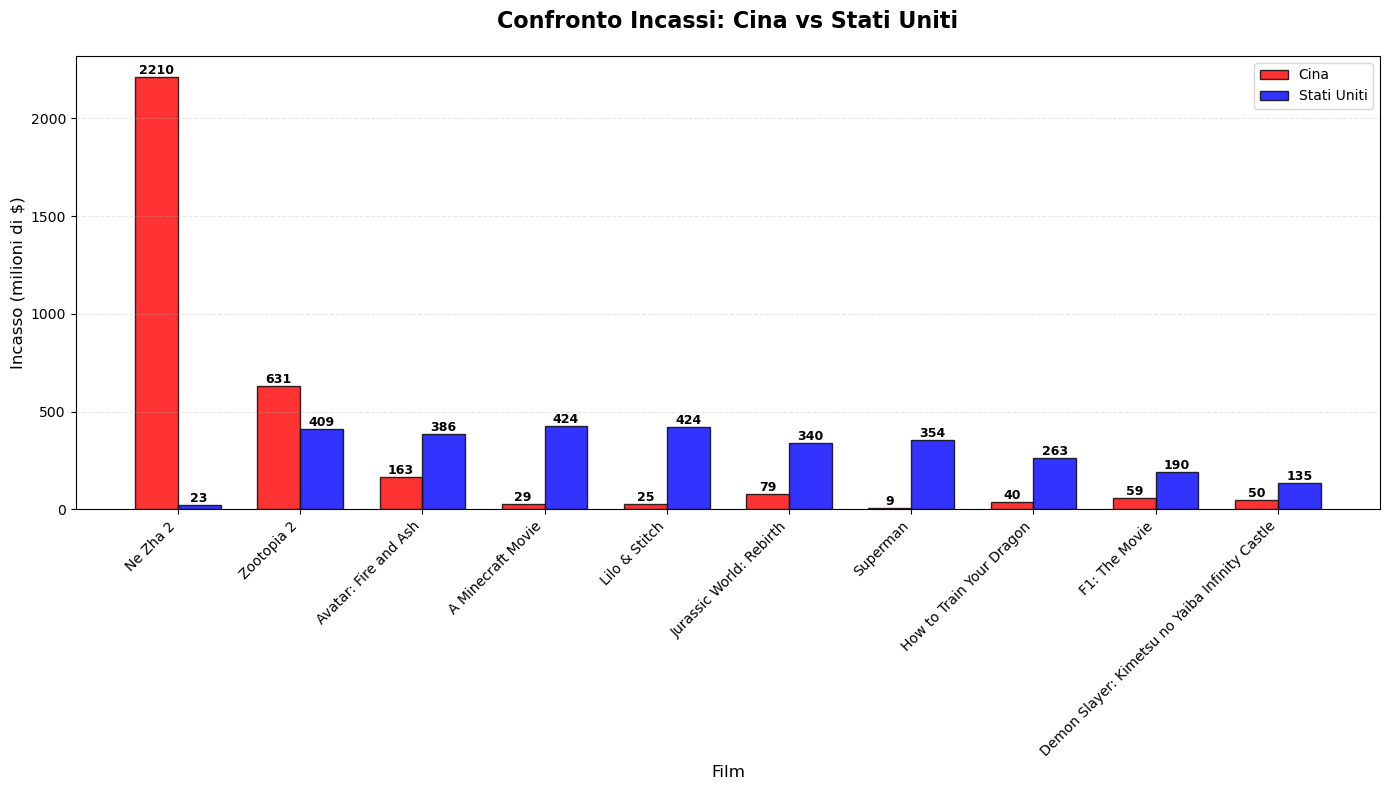

Incassi in milioni di $:
                                                China  America
Nome film                                                     
Ne Zha 2                                         2210       23
Zootopia 2                                        631      409
Avatar: Fire and Ash                              163      386
A Minecraft Movie                                  29      424
Lilo & Stitch                                      25      424
Jurassic World: Rebirth                            79      340
Superman                                            9      354
How to Train Your Dragon                           40      263
F1: The Movie                                      59      190
Demon Slayer: Kimetsu no Yaiba Infinity Castle     50      135


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica i dati
df = pd.read_csv('Nazione - Foglio1 (1).csv', skiprows=1)
df = df.set_index('Nome film')

# Funzione per convertire i valori
def convert_value(x):
    if x == '-':
        return 0
    elif isinstance(x, str):
        return float(x.replace('$', '').replace(',', ''))
    return float(x)

df_numeric = df.map(convert_value)

# Seleziona solo Cina e America
paesi_selezionati = ['China', 'America']
dati_paesi = df_numeric[paesi_selezionati].copy()

# Converti in milioni per leggibilità
dati_paesi_milioni = dati_paesi / 1000000

# Ordina per incasso totale (opzionale)
dati_paesi_milioni['Totale'] = dati_paesi_milioni.sum(axis=1)
dati_paesi_milioni = dati_paesi_milioni.sort_values('Totale', ascending=False)
dati_paesi_milioni = dati_paesi_milioni.drop(columns='Totale')

# Imposta la larghezza delle barre
x = np.arange(len(dati_paesi_milioni.index))
width = 0.35

# Crea il grafico a barre affiancate
plt.figure(figsize=(14, 8))

# Barre per Cina
bars_cina = plt.bar(x - width/2, dati_paesi_milioni['China'], 
                    width, label='Cina', color='red', alpha=0.8, edgecolor='black')

# Barre per America
bars_usa = plt.bar(x + width/2, dati_paesi_milioni['America'], 
                   width, label='Stati Uniti', color='blue', alpha=0.8, edgecolor='black')

# Personalizza
plt.title('Confronto Incassi: Cina vs Stati Uniti', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Film', fontsize=12)
plt.ylabel('Incasso (milioni di $)', fontsize=12)
plt.xticks(x, dati_paesi_milioni.index, rotation=45, ha='right')
plt.legend()

# Aggiungi griglia
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Aggiungi valori sulle barre (solo se significativi)
for bars in [bars_cina, bars_usa]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Mostra solo valori > 0
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{height:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostra anche la tabella dei dati
print("Incassi in milioni di $:")
print(dati_paesi_milioni.round(0).astype(int))